In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix
import seaborn as sns
from sklearn.calibration import calibration_curve

In [2]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df['encoded_igi_call'] = 1*(groundtruth_df.igi_call == 'Positive')
groundtruth_df['groundtruth_label'] = 1*(groundtruth_df.groundtruth == 1)


In [3]:
fusion_vit_test_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_test_pred_df.csv')
fusion_vit_test_pred = (fusion_vit_test_pred
           .merge(groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates(), 
                  how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
fusion_vit_test_pred = fusion_vit_test_pred.rename(columns={'prob':'outputs'})

In [4]:
fusion_val_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_val_pred_df.csv')
fusion_train_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_train_pred_df.csv')
fusion_test_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_train_pred_df.csv')

fusion_train_pred = pd.concat([fusion_train_pred, fusion_val_pred, fusion_test_pred])

fusion_train_pred = (fusion_train_pred
           .merge(groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates(), 
                  how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
fusion_train_pred = fusion_train_pred.rename(columns={'prob':'outputs'})

In [5]:
fusion_vit_retest_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_retest_pred_df.csv')
retest_df = (fusion_vit_retest_pred
 .merge(join_df[['sample_id','curve_idx','target','igi_call','final_patient_result','current_sample_result']].drop_duplicates(),
        how = 'inner', on = 'curve_idx'))

retest_df['encoded_igi_call'] = 1*(retest_df.igi_call == 'Positive')
retest_df['groundtruth_label'] = 0
retest_df.loc[retest_df.target.isin(['RnaseP','MS2']), 'groundtruth_label'] = 1
retest_df.loc[(retest_df.target.isin(['RnaseP','MS2'])) & (retest_df.final_patient_result == 'Positive'), 'groundtruth_label'] = 1

In [6]:
pd.set_option('display.max_columns', None)
dd = join_df.loc[(join_df.retest_sample_id_1 != ' ') & (join_df.cycle_no == 40)]

dd.groupby('current_sample_result').sample_id.nunique()

current_sample_result
Inconclusive    324
Invalid         903
Negative          8
Positive          1
Name: sample_id, dtype: int64

## All numbers related to IGI method
### 1) The current IGI threshold-based PCR-test evaluation system is imperfect 
a.Overall system has a low false positive rate


In [7]:
df = groundtruth_df[['sample_id','curve_idx','target','groundtruth_label','encoded_igi_call']].drop_duplicates()
fpr = (df[(df.encoded_igi_call == 1) & (df.groundtruth_label == 0)].shape[0]/
      df[(df.encoded_igi_call == 1)].shape[0]*100)
print(f'IGI false positive rate on control curves is {round(fpr,2)}%.')

IGI false positive rate on control curves is 0.03%.


b) But there are several false negative tests both at the curve and at the sample level 

In [8]:
control_fnr = (df[(df.encoded_igi_call == 0) & (df.groundtruth_label == 1)].shape[0]/
               df[df.encoded_igi_call == 0].shape[0])*100
print(f'IGI false negative rate on control curves is {round(control_fnr,2)}%.')


IGI false negative rate on control curves is 28.03%.


In [9]:
control_sample_df = (groundtruth_df[['sample_id','curve_idx','target','groundtruth_label','encoded_igi_call']].drop_duplicates()
                     .merge(join_df.loc[join_df.sample_type != 'Clinical Sample',['curve_idx','current_sample_result','sample_type']].drop_duplicates(),
                            on = 'curve_idx', how='inner')
 .groupby(['current_sample_result','sample_type'])
 .sample_id.nunique().reset_index())

inconclusive_rate = control_sample_df[control_sample_df.current_sample_result == 'Invalid'].shape[0]/control_sample_df.shape[0]
print(f'We have 64 human normal negative control samples in test set with 5 samples labeled as invalid.')
print(f'IGI control sample inconclusive rate is {round(inconclusive_rate,2)}%.')

We have 64 human normal negative control samples in test set with 5 samples labeled as invalid.
IGI control sample inconclusive rate is 0.5%.


In [10]:
clinical_sample_df = (join_df
 .loc[(join_df.sample_type == 'Clinical Sample'), ['sample_id','current_sample_result','final_patient_result','retest_sample_id_1','retest_sample_id_2']]
 .drop_duplicates())
retest_rate = clinical_sample_df[(clinical_sample_df.retest_sample_id_1 != ' ')].shape[0]/clinical_sample_df.shape[0]
print(f'IGI retest rate is {round(retest_rate,2)}%.')

IGI retest rate is 0.06%.


In [11]:
retest_twice_rate = clinical_sample_df.loc[clinical_sample_df.retest_sample_id_2 != ' '].shape[0]/clinical_sample_df.shape[0]
retest_retest_rate = clinical_sample_df.loc[clinical_sample_df.retest_sample_id_2 != ' '].shape[0]/clinical_sample_df[clinical_sample_df.retest_sample_id_1 != ' '].shape[0]
print(f'IGI retest rate twice is {round(retest_twice_rate, 2)}%.')
print(f'IGI retest retest rate twice is {round(retest_retest_rate,2)}%.')

IGI retest rate twice is 0.01%.
IGI retest retest rate twice is 0.11%.


In [96]:
test_igi_auc = roc_auc_score(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call)

igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call).ravel()

igi_precision = igi_tp/(igi_fp + igi_tp)
igi_sensitivity = igi_tp/(igi_tp + igi_fn)
igi_specificity = igi_tn/(igi_tn + igi_fp)
igi_f1 = 2*igi_tp/(2*igi_tp + igi_fp + igi_fn)
igi_acc = (igi_tp+igi_tn)/(igi_tp+igi_tn+igi_fp+igi_fn)
igi_fnr = igi_fn/(igi_fn + igi_tn)
igi_fpr = igi_fp/(igi_fp+igi_tp)
igi_tpr = (igi_tp)/(igi_tp + igi_fp)

print('--------------')
print('On Test set curves')
print('--------------')
print('IGI AUC:', test_igi_auc)
print(f'IGI accuracy: {igi_acc}')
print(f'IGI precision: {igi_precision}')
print(f'IGI sensitivity: {igi_sensitivity}')
print(f'IGI F1 score: {igi_f1}')
print(f'IGI TP = {igi_tp}; TN = {igi_tn}; FP = {igi_fp}; FN = {igi_fn}')
print(f'IGI FNR = {igi_fnr} and FPR = {igi_fpr}')


retest_igi_tn, retest_igi_fp, retest_igi_fn, retest_igi_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.encoded_igi_call).ravel()

retest_igi_precision = retest_igi_tp/(retest_igi_fp + retest_igi_tp)
retest_igi_sensitivity = retest_igi_tp/(retest_igi_tp + retest_igi_fn)
retest_igi_specificity = retest_igi_tn/(retest_igi_tn + retest_igi_fp)
retest_igi_f1 = 2*retest_igi_tp/(2*retest_igi_tp + retest_igi_fp + retest_igi_fn)
retest_igi_acc = (retest_igi_tp+retest_igi_tn)/(retest_igi_tp+retest_igi_tn+retest_igi_fp+retest_igi_fn)
retest_igi_fnr = retest_igi_fn/(retest_igi_fn + retest_igi_tn)
retest_igi_fpr = retest_igi_fp/(retest_igi_fp+retest_igi_tp)
retest_igi_tpr = (retest_igi_tp)/(retest_igi_tp + retest_igi_fp)

print('--------------')
print('On Retest set curves')
print('--------------')
print(f'IGI retest accuracy: {retest_igi_acc}')
print(f'IGI retest precision: {igi_precision}')
print(f'IGI retest sensitivity: {igi_sensitivity}')
print(f'IGI retest F1 score: {retest_igi_f1}')
print(f'IGI retest TP = {retest_igi_tp}; TN = {retest_igi_tn}; FP = {retest_igi_fp}; FN = {retest_igi_fn}')
print(f'IGI retest FNR = {igi_fnr} and FPR = {retest_igi_fpr}')

retest_sample = retest_df.copy()
retest_sample['encoded_igi_call'] = 1*(retest_sample.igi_call == 'Positive')

invalid_igi_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.encoded_igi_call == 0)]

retest_sample_df = (retest_sample
                    .loc[~retest_sample.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(igi_prob = ('encoded_igi_call', 'mean'))
 .reset_index())
retest_sample_df['igi_pred'] = None
retest_sample_df.loc[retest_sample_df.igi_prob > 0.5, 'igi_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.igi_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_igi_sample_id)), 'igi_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.igi_prob == 0) & (retest_sample_df.sample_id.isin(invalid_igi_sample_id)), 'igi_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.igi_prob > 0) & (retest_sample_df.igi_prob <= 0.5), 'igi_pred'] = 'Inconclusive'
retest_sample_df['igi_pred_3'] = retest_sample_df.igi_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.igi_pred_3, labels = ['Negative','Positive','ReSample'])
igi_algo_retest_sample_rate = cm.sum(axis=0)[2]/retest_sample_df.shape[0]
print('-------------')
print('On Retest sample level')
print('-------------')
print(f'IGI accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=0).sum())}')
print(f'IGI FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'IGI FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'IGI Resample Rate: {igi_algo_retest_sample_rate}')

igi_actual_retest_rate = retest_sample_df[retest_sample_df.current_sample_result_3 == 'ReSample'].shape[0]/retest_sample_df.shape[0]
print('-------------')
print(f'IGI actual resample rate: {igi_actual_retest_rate}')
print('-------------')

--------------
On Test set curves
--------------
IGI AUC: 0.9773955331412103
IGI accuracy: 0.9593522267206478
IGI precision: 1.0
IGI sensitivity: 0.9547910662824207
IGI F1 score: 0.9768727540772136
IGI TP = 5301; TN = 623; FP = 0; FN = 251
IGI FNR = 0.28718535469107553 and FPR = 0.0
--------------
On Retest set curves
--------------
IGI retest accuracy: 0.7661606268364348
IGI retest precision: 1.0
IGI retest sensitivity: 0.9547910662824207
IGI retest F1 score: 0.6356352537199542
IGI retest TP = 833; TN = 2296; FP = 552; FN = 403
IGI retest FNR = 0.28718535469107553 and FPR = 0.39855595667870036
-------------
On Retest sample level
-------------
IGI accuracy: 0.5970873786407767
IGI FNR: 0.07588075880758804
IGI FPR: 0.2075471698113207
IGI Resample Rate: 0.36003236245954695
-------------
IGI actual resample rate: 0.9927184466019418
-------------


Text(0.5, 1.0, 'IGI Algorithm on Retest')

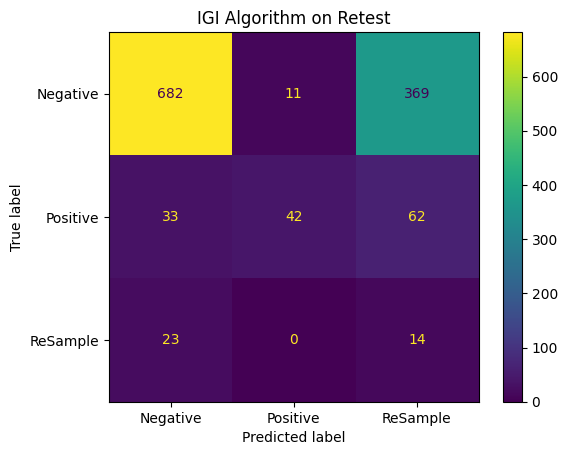

In [84]:
cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.igi_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('IGI Algorithm on Retest')

Text(0.5, 1.0, 'IGI Manual on Retest')

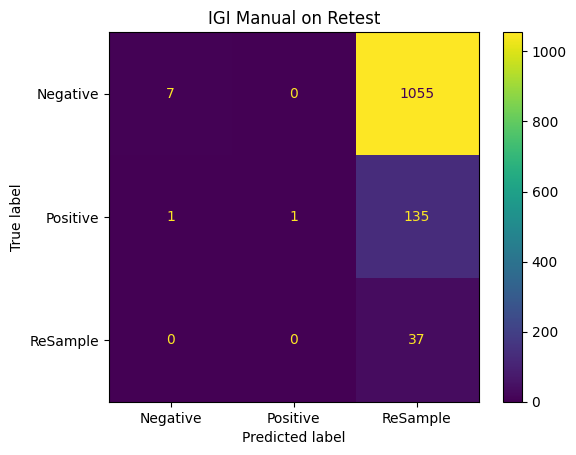

In [85]:

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.current_sample_result_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('IGI Manual on Retest')

c) This performance problems may be driven by the simple threshold-based classification rule implemented by the IGI, which neglects further information provided by the complete amplification trajectory
### Manually pick out curves

In [11]:
pd.set_option('display.max_rows', None)
(groundtruth_df
#  .loc[groundtruth_df.encoded_igi_call != groundtruth_df.groundtruth_label,
 .loc[(groundtruth_df.encoded_igi_call == 0) & (groundtruth_df.groundtruth_label == 1),
      ['curve_idx','encoded_igi_call','groundtruth_label']].drop_duplicates()
 .merge(join_df[['curve_idx','sample_type','target','well_position','amp_score','record_type','file']].drop_duplicates(), 
        how='inner', on='curve_idx')
 .merge(fusion_vit_test_pred[['curve_idx','outputs']], how='inner', on='curve_idx')
 .sort_values(['outputs','amp_score']))

,curve_idx,encoded_igi_call,groundtruth_label,sample_type,target,well_position,amp_score,record_type,file,outputs
1,52562,0,1,Positive Control (qPCR),E gene,N19,1.720351,Control Sample,gxwf,0.001941
0,52538,0,1,Positive Control (qPCR),E gene,M19,0.000000,Control Sample,gxwf,0.002849
2,52564,0,1,Positive Control (qPCR),E gene,N20,0.000000,Control Sample,gxwf,0.004409
232,6608,0,1,Clinical Sample,MS2,E1,0.000000,Submitted Sample,darv,0.047360
196,31798,0,1,Clinical Sample,MS2,I13,0.000000,Submitted Sample,dbjb,0.068387
243,7389,0,1,Clinical Sample,MS2,C7,1.429761,Submitted Sample,darx,0.079091
238,119843,0,1,Clinical Sample,RnaseP,A5,0.000000,Submitted Sample,h0yg,0.116568
224,108558,0,1,Clinical Sample,RnaseP,K22,1.234355,Re-Test Sample,h0vk,0.141297
197,31859,0,1,Clinical Sample,MS2,M3,1.512374,Pooled Sample,dbjb,0.156488
24,107368,0,1,Clinical Sample,RnaseP,J1,0.000000,Pooled Sample,h0v8,0.162188


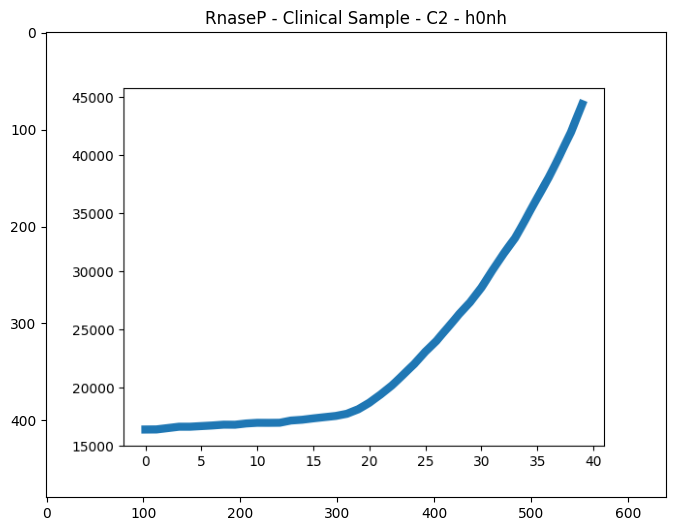

In [12]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

fig = plt.figure(frameon=False)
fig.set_size_inches(8,10)

img = mpimg.imread('../data/curve_imgs_axis/curve_81867.png')
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
# fig.add_axes(ax)
# ax.bar_label(ax.containers[0])
# plt.title('Contribution')

plt.title('RnaseP - Clinical Sample - C2 - h0nh')
plt.imshow(img)
plt.show()

### High level analysis on retest samples

In [12]:
dd = join_df.loc[(join_df.retest_sample_id_1 != ' ') & (join_df.cycle_no == 40)]

dd.groupby('current_sample_result').sample_id.nunique()

current_sample_result
Inconclusive    324
Invalid         903
Negative          8
Positive          1
Name: sample_id, dtype: int64

In [13]:
dd.loc[(dd.current_sample_result == 'Inconclusive') & 
       (dd.final_patient_result == 'Negative') & 
       (~dd.target.isin(['MS2','RnaseP'])) &
       (dd.igi_call == 'Positive')].groupby(['target']).curve_idx.nunique()

target
E gene     18
N gene    176
ORF1ab     25
S gene     37
Name: curve_idx, dtype: int64

### 2) We have developed a machine learning model that surpasses the accuracy of the IGI on a test set of control samples
#### a) AUC


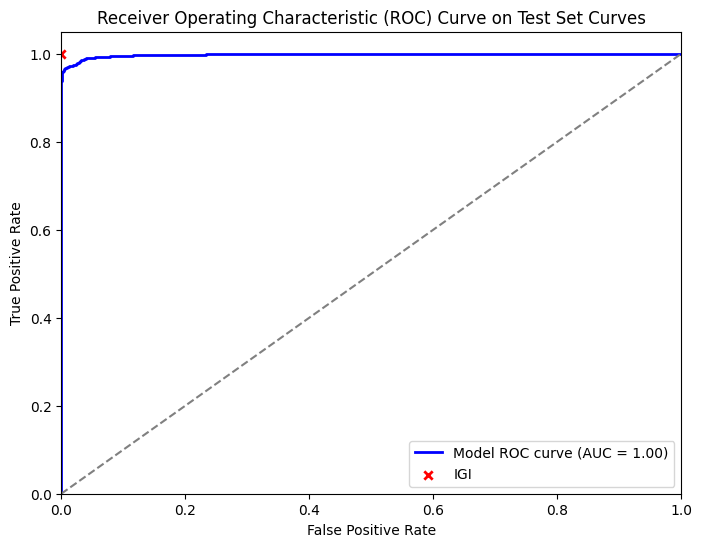

In [75]:

test_auc = roc_auc_score(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
# plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.scatter(igi_fpr, igi_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set Curves')
plt.legend(loc='lower right')
plt.show()


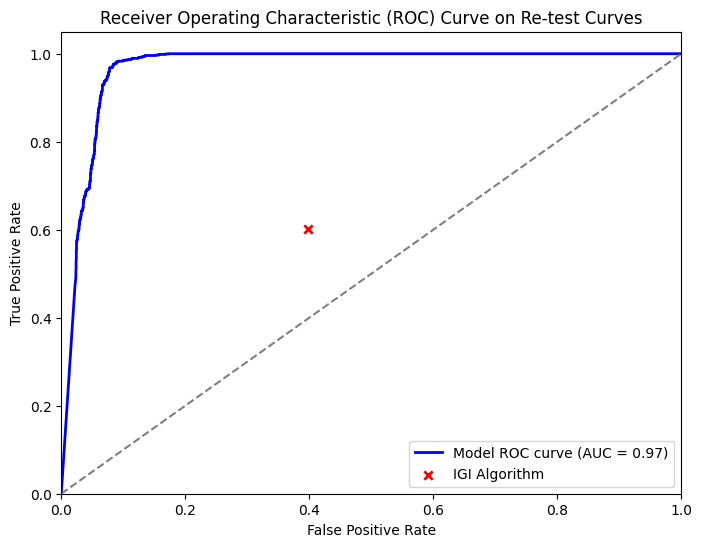

In [76]:
retest_auc = roc_auc_score(retest_df.groundtruth_label, retest_df.outputs)
retest_fpr, retest_tpr, retest_thresholds = roc_curve(retest_df.groundtruth_label, retest_df.outputs)

plt.figure(figsize=(8, 6))
plt.plot(retest_fpr, retest_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(retest_auc))
# plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.scatter(retest_igi_fpr, retest_igi_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI Algorithm')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Re-test Curves')
plt.legend(loc='lower right')
plt.show()


In [77]:
## test set
thresholds = np.linspace(0.1, 1, 1000)
tns, tps, fns, fps = [], [], [], []
for thres in thresholds:
    pred = 1*(fusion_vit_test_pred.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, pred).ravel()
    tns.append(tn)
    tps.append(tp)
    fns.append(fn)
    fps.append(fp)

tns, tps, fns, fps = np.array(tns), np.array(tps), np.array(fns), np.array(fps)

accuracy = (tps+tns)/(tps+tns+fps+fns)
precision = (tps)/(tps + fps)
sensitivity = (tps)/(tps + fns)
neg_preds = fns + tns
f1_scores = 2*tps/(2*tps + fps + fns)
fpr = fps/(fps + tps)
fnr = fns/(fns + tns)

## retest set
retest_tns, retest_tps, retest_fns, retest_fps = [], [], [], []
for thres in thresholds:
    pred = 1*(retest_df.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(retest_df.groundtruth_label, pred).ravel()
    retest_tns.append(tn)
    retest_tps.append(tp)
    retest_fns.append(fn)
    retest_fps.append(fp)

retest_tns, retest_tps, retest_fns, retest_fps = np.array(retest_tns), np.array(retest_tps), np.array(retest_fns), np.array(retest_fps)

retest_accuracy = (retest_tps+retest_tns)/(retest_tps+retest_tns+retest_fps+retest_fns)
retest_precision = (retest_tps)/(retest_tps + retest_fps)
retest_sensitivity = (retest_tps)/(retest_tps + retest_fns)
retest_neg_preds = retest_fns + retest_tns
retest_f1_scores = 2*retest_tps/(2*retest_tps + retest_fps + retest_fns)
retest_fpr = retest_fps/(retest_fps + retest_tps)
retest_fnr = retest_fns/(retest_fns + retest_tns)



a) Picking threshold based on criteria
* Best accuracy

In [78]:
idx = accuracy.argmax()
best_acc_threshold = thresholds[idx]
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.5657657657657658
With accuracy: 0.9872064777327936
With precision: 0.9938639234795164
With sensitivity: 0.9918948126801153
With F1 score: 0.9928783917785992
With TP = 5507; TN = 589; FP = 34; FN = 45
With FNR = 0.07097791798107256 and FPR = 0.006136076520483667


In [79]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.9324191968658179
With precision: 0.8448275862068966
With sensitivity: 0.9514563106796117
With F1 score: 0.8949771689497716
With TP = 1176; TN = 2632; FP = 216; FN = 60
With FNR = 0.022288261515601784 and FPR = 0.15517241379310345


Text(0.5, 1.0, 'Best Accuracy Threshold on Retest')

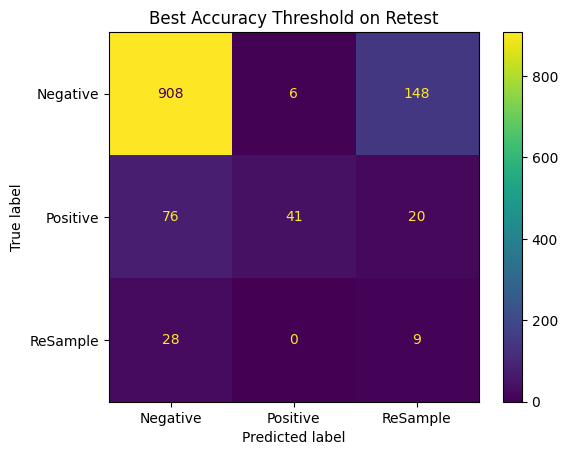

In [80]:
retest_sample = retest_df.copy()
retest_sample['pred'] = 1*(retest_sample.outputs >= thresholds[idx])
retest_sample['encoded_igi_call'] = 1*(retest_sample.igi_call == 'Positive')

invalid_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.pred == 0)].sample_id

# model prediction
retest_sample_df = (retest_sample
                    .loc[~retest_sample.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'),
      igi_prob = ('encoded_igi_call', 'mean'))
 .reset_index())

retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Accuracy Threshold on Retest')

* Best sensitivity

Since there is multplie thresholds that give the same maximum sensitivity, we pick the threshold that also has maximum precision and accuracy, lowest false negative rate and false positive rate among the group. 

In [26]:
ids = np.where(sensitivity == sensitivity.max())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [27]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.11621621621621622
With accuracy: 0.9685829959514171
With precision: 0.9675392670157068
With sensitivity: 0.9985590778097982
With F1 score: 0.9828044672930332
With TP = 5544; TN = 437; FP = 186; FN = 8
With FNR = 0.017977528089887642 and FPR = 0.032460732984293195


In [28]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.9047502448579824
With precision: 0.7628801986343886
With sensitivity: 0.9943365695792881
With F1 score: 0.8633649455567264
With TP = 1229; TN = 2466; FP = 382; FN = 7
With FNR = 0.0028305701577031944 and FPR = 0.23711980136561142


Text(0.5, 1.0, 'Best Sensitivity Threshold on Retest')

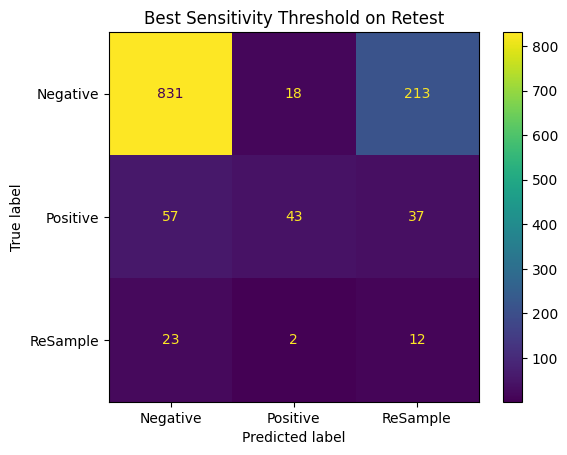

In [29]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Sensitivity Threshold on Retest')

* Best precision

Since there is multplie thresholds that give the same maximum precision, we pick the threshold that also has maximum sensitivity and accuracy, lowest false negative rate and false positive rate among the group. 

In [30]:
ids = np.where(precision == precision.max())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_scores': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [31]:
idx = df.sort_values('sensitivity', ascending=False).reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.3597122302158273 and FPR = 0.0


In [32]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8756121449559255
With precision: 0.8872340425531915
With sensitivity: 0.6747572815533981
With F1 score: 0.7665441176470589
With TP = 834; TN = 2742; FP = 106; FN = 402
With FNR = 0.12786259541984732 and FPR = 0.1127659574468085


Text(0.5, 1.0, 'Best Precision Threshold on Retest')

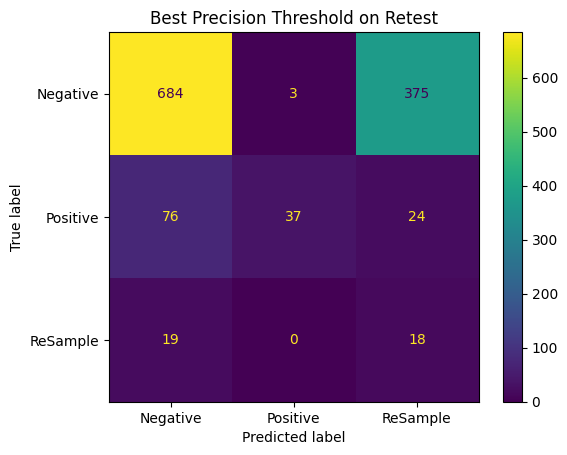

In [33]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision Threshold on Retest')

* Best f1 score

In [34]:
idx = f1_scores.argmax()
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.5657657657657658
With accuracy: 0.9872064777327936
With precision: 0.9938639234795164
With sensitivity: 0.9918948126801153
With F1 score: 0.9928783917785992
With TP = 5507; TN = 589; FP = 34; FN = 45
With FNR = 0.07097791798107256 and FPR = 0.006136076520483667


In [35]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.9324191968658179
With precision: 0.8448275862068966
With sensitivity: 0.9514563106796117
With F1 score: 0.8949771689497716
With TP = 1176; TN = 2632; FP = 216; FN = 60
With FNR = 0.022288261515601784 and FPR = 0.15517241379310345


Text(0.5, 1.0, 'Best Accuracy / F1 Score Threshold on Retest')

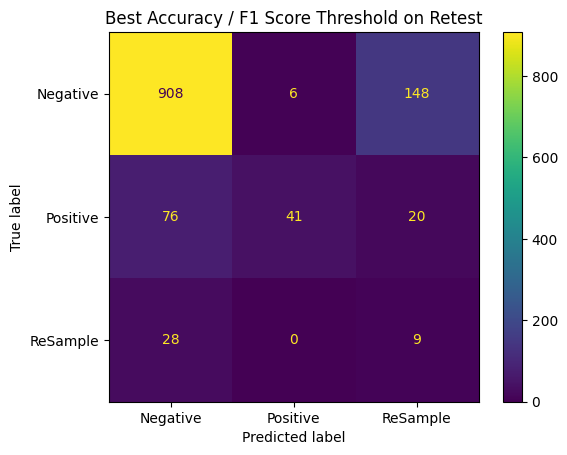

In [36]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Accuracy / F1 Score Threshold on Retest')

* Best false negative rate

In [37]:
idx = fnr.argmin()
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.11621621621621622
With accuracy: 0.9685829959514171
With precision: 0.9675392670157068
With sensitivity: 0.9985590778097982
With F1 score: 0.9828044672930332
With TP = 5544; TN = 437; FP = 186; FN = 8
With FNR = 0.017977528089887642 and FPR = 0.032460732984293195


In [38]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.9047502448579824
With precision: 0.7628801986343886
With sensitivity: 0.9943365695792881
With F1 score: 0.8633649455567264
With TP = 1229; TN = 2466; FP = 382; FN = 7
With FNR = 0.0028305701577031944 and FPR = 0.23711980136561142


Text(0.5, 1.0, 'Best Sensitivity / False Negative Rate Threshold on Retest')

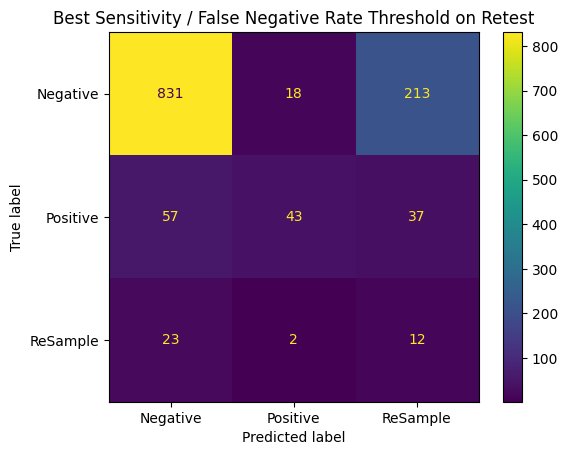

In [39]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Sensitivity / False Negative Rate Threshold on Retest')

* Best false positive rate

In [40]:
ids = np.where(fpr == fpr.min())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [41]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.3597122302158273 and FPR = 0.0


In [42]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8756121449559255
With precision: 0.8872340425531915
With sensitivity: 0.6747572815533981
With F1 score: 0.7665441176470589
With TP = 834; TN = 2742; FP = 106; FN = 402
With FNR = 0.12786259541984732 and FPR = 0.1127659574468085


Text(0.5, 1.0, 'Best Precision / False Positive Rate Threshold on Retest')

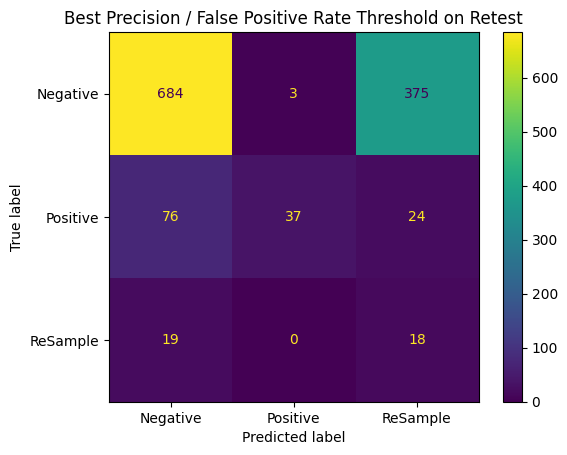

In [43]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision / False Positive Rate Threshold on Retest')

b) Picking threshold based on matching metrics with igi_acc
* False Positive Rate

In [44]:
ids = np.where(fpr == igi_fpr)

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])

In [45]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'IGI fpr: {igi_fpr}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI fpr: 0.0
Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.3597122302158273 and FPR = 0.0


In [46]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8756121449559255
With precision: 0.8872340425531915
With sensitivity: 0.6747572815533981
With F1 score: 0.7665441176470589
With TP = 834; TN = 2742; FP = 106; FN = 402
With FNR = 0.12786259541984732 and FPR = 0.1127659574468085


Text(0.5, 1.0, 'Best Precision/ Best FPR / Matching False Positive Rate Threshold on Retest')

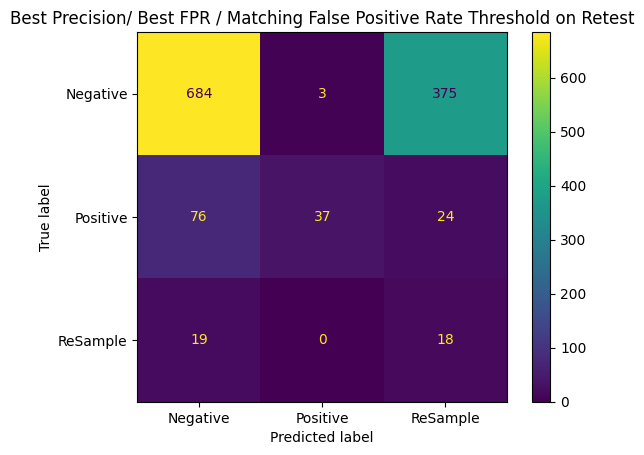

In [47]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision/ Best FPR / Matching False Positive Rate Threshold on Retest')

* False negative rate

In [48]:
idx = np.where(np.round(fnr,3) == round(igi_fnr,3))[0][0]
print(f'IGI fnr: {igi_fnr}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI fnr: 0.28718535469107553
Model AUC: 0.997836882057165
We use threshold at: 0.9783783783783784
With accuracy: 0.9593522267206478
With precision: 0.9998114274938714
With sensitivity: 0.954971181556196
With F1 score: 0.9768770152003685
With TP = 5302; TN = 622; FP = 1; FN = 250
With FNR = 0.286697247706422 and FPR = 0.00018857250612860644


In [49]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8854064642507345
With precision: 0.8692307692307693
With sensitivity: 0.7313915857605178
With F1 score: 0.7943760984182777
With TP = 904; TN = 2712; FP = 136; FN = 332
With FNR = 0.10906701708278581 and FPR = 0.13076923076923078


Text(0.5, 1.0, 'Matching False Negative Rate Threshold on Retest')

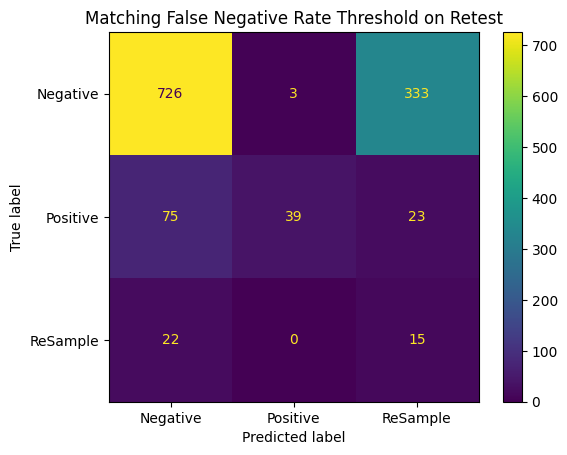

In [50]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching False Negative Rate Threshold on Retest')

* Positive predictions

In [51]:
idx = np.where((tps + fps) == (igi_tp + igi_fp))[0][0]
print(f'IGI number of positive prediction: {igi_tp + igi_fp}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI number of positive prediction: 5301
Model AUC: 0.997836882057165
We use threshold at: 0.9792792792792793
With accuracy: 0.9590283400809717
With precision: 0.9998113563478589
With sensitivity: 0.9546109510086456
With F1 score: 0.9766884732332074
With TP = 5300; TN = 622; FP = 1; FN = 252
With FNR = 0.28832951945080093 and FPR = 0.00018864365214110544


In [52]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.8844270323212536
With precision: 0.8694390715667312
With sensitivity: 0.7273462783171522
With F1 score: 0.7920704845814978
With TP = 899; TN = 2713; FP = 135; FN = 337
With FNR = 0.11049180327868853 and FPR = 0.13056092843326886


Text(0.5, 1.0, 'Matching Positive Prediction Threshold on Retest')

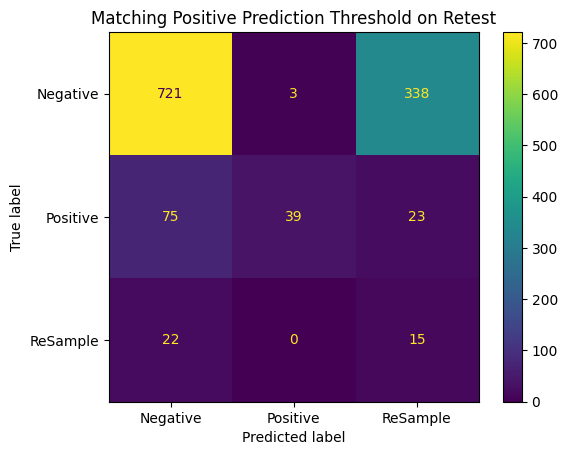

In [53]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching Positive Prediction Threshold on Retest')

* Negative Predictions

In [54]:
idx = np.where((fns + tns) == (igi_fn + igi_tn))[0][0]
print(f'IGI number of negative prediction: {igi_tn + igi_fn}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI number of negative prediction: 874
Model AUC: 0.997836882057165
We use threshold at: 0.9792792792792793
With accuracy: 0.9590283400809717
With precision: 0.9998113563478589
With sensitivity: 0.9546109510086456
With F1 score: 0.9766884732332074
With TP = 5300; TN = 622; FP = 1; FN = 252
With FNR = 0.28832951945080093 and FPR = 0.00018864365214110544


Text(0.5, 1.0, 'Matching Positive / Negative Prediction Threshold on Retest')

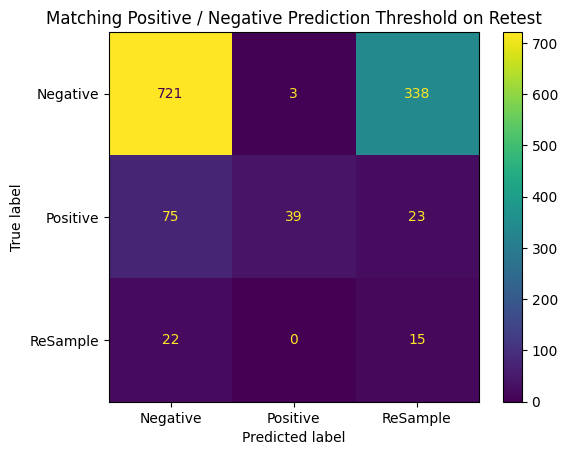

In [55]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching Positive / Negative Prediction Threshold on Retest')

### Extra Plots

[]

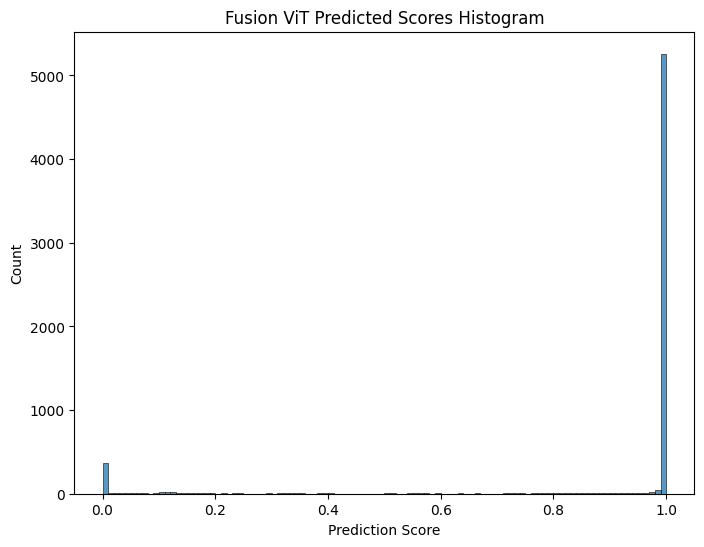

In [56]:
plt.figure(figsize=(8, 6))
sns.histplot(fusion_vit_test_pred, x = 'outputs', binwidth=0.01)
plt.title('Fusion ViT Predicted Scores Histogram')
plt.xlabel('Prediction Score')
plt.plot()

Text(0.5, 0, 'False Positive Rate')

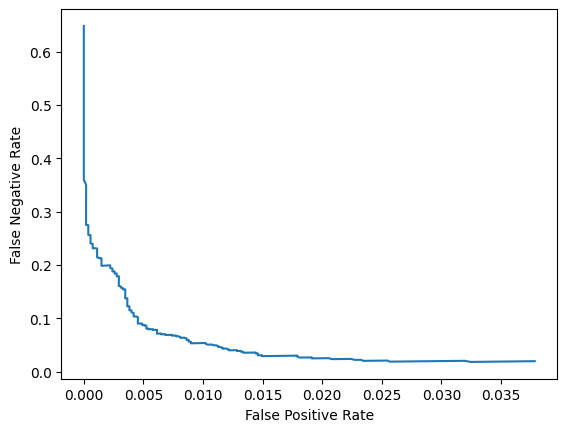

In [57]:
plt.plot(fpr, fnr)
plt.ylabel('False Negative Rate')
plt.xlabel('False Positive Rate')

[]

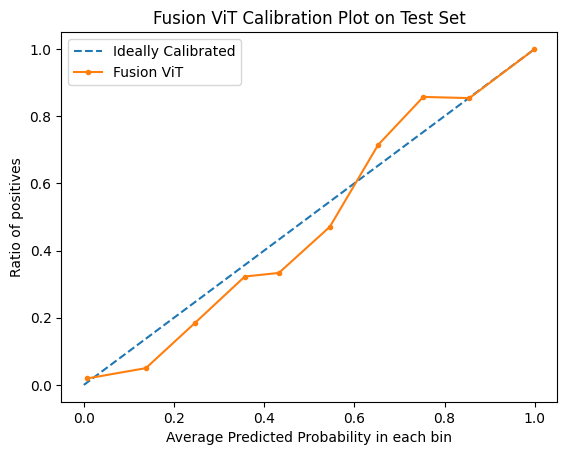

In [58]:
x,y = calibration_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Fusion ViT Calibration Plot on Test Set')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()

[]

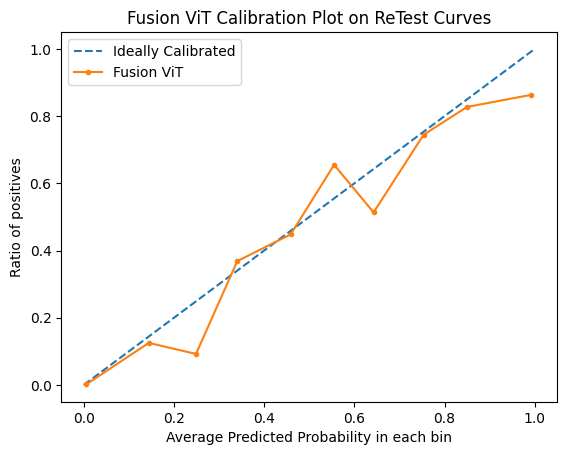

In [59]:
calibration_df = (retest_df
.merge(fusion_vit_retest_pred[['outputs','curve_idx']]))

x,y = calibration_curve(calibration_df.groundtruth_label, calibration_df.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Fusion ViT Calibration Plot on ReTest Curves')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()

#### Deep Dive Analysis in Best Accuracy Model

In [88]:
retest_sample = retest_df.copy()
retest_sample['pred'] = 1*(retest_sample.outputs >= best_acc_threshold)
retest_sample['encoded_igi_call'] = 1*(retest_sample.igi_call == 'Positive')

invalid_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.pred == 0)].sample_id
invalid_igi_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.encoded_igi_call == 0)]

# model prediction
retest_sample_df = (retest_sample
                    .loc[~retest_sample.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'),
      igi_prob = ('encoded_igi_call', 'mean'))
 .reset_index())

retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

retest_sample_df['igi_pred'] = None
retest_sample_df.loc[retest_sample_df.igi_prob > 0.5, 'igi_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.igi_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_igi_sample_id)), 'igi_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.igi_prob == 0) & (retest_sample_df.sample_id.isin(invalid_igi_sample_id)), 'igi_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.igi_prob > 0) & (retest_sample_df.igi_prob <= 0.5), 'igi_pred'] = 'Inconclusive'
retest_sample_df['igi_pred_3'] = retest_sample_df.igi_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

best_acc_retest_df = (retest_sample
 .merge(retest_sample_df[['sample_id','sample_pred','igi_pred','sample_pred_3','igi_pred_3']], how='inner', on = 'sample_id'))

In [89]:
best_acc_retest_df.groupby('sample_pred').sample_id.nunique()

sample_pred
Inconclusive     122
Invalid           55
Negative        1012
Positive          47
Name: sample_id, dtype: int64

In [90]:
best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Inconclusive') &
                       (~best_acc_retest_df.target.isin(['MS2','RnaseP'])) &
                       (best_acc_retest_df.final_patient_result == 'Negative') &
                       (best_acc_retest_df.pred == 1)].groupby('target').curve_idx.nunique()

target
E gene     9
N gene    23
ORF1ab    34
S gene    34
Name: curve_idx, dtype: int64

In [91]:
fn_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Negative') & 
                       (best_acc_retest_df.final_patient_result == 'Positive')].sample_id.nunique()
agree_fn_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Negative') & 
                       (best_acc_retest_df.final_patient_result == 'Positive') &
                       (best_acc_retest_df.sample_pred == best_acc_retest_df.igi_pred)
                       ].sample_id.nunique()
print(f'Number of False Negative: {fn_retest}')
print(f'Number of argreed False Negative between our model and IGI: {agree_fn_retest}')

Number of False Negative: 76
Number of argreed False Negative between our model and IGI: 31


In [92]:
fp_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Positive') & 
                       (best_acc_retest_df.final_patient_result == 'Negative')].sample_id.nunique()
agree_fp_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred == 'Positive') & 
                       (best_acc_retest_df.final_patient_result == 'Negative') &
                       (best_acc_retest_df.sample_pred == best_acc_retest_df.igi_pred)
                       ].sample_id.nunique()
print(f'Number of False Positive: {fp_retest}')
print(f'Number of argreed False Positive between our model and IGI: {agree_fp_retest}')

Number of False Positive: 6
Number of argreed False Positive between our model and IGI: 6


In [93]:
negative_resample_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred_3 == 'ReSample') & 
                       (best_acc_retest_df.final_patient_result == 'Negative')].sample_id.nunique()
miss_negative_resample_retest = best_acc_retest_df.loc[(best_acc_retest_df.sample_pred_3 == 'ReSample') & 
                       (best_acc_retest_df.final_patient_result == 'Negative') &
                       (best_acc_retest_df.final_patient_result == best_acc_retest_df.igi_pred_3)
                       ].sample_id.nunique()
print(f'Number of samples our model predicts to be resampled and groundtruth is Negative: {negative_resample_retest}')
print(f'Number of samples our model predicts to be resampled but IGI algorithm predicts correctly to be negative: {miss_negative_resample_retest}')

Number of samples our model predicts to be resampled and groundtruth is Negative: 148
Number of samples our model predicts to be resampled but IGI algorithm predicts correctly to be negative: 53


[]

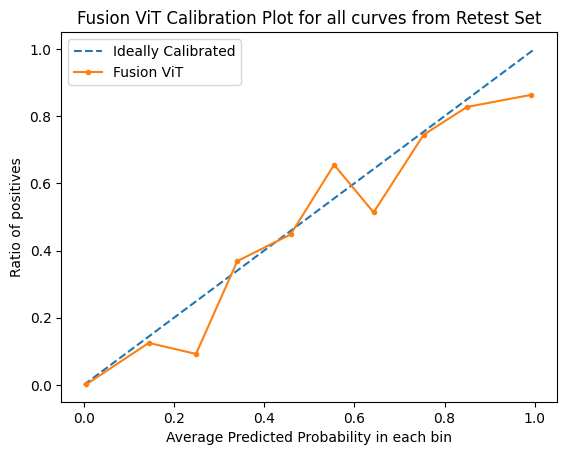

In [94]:
calibration_df = (retest_df
.merge(fusion_vit_retest_pred[['outputs','curve_idx']]))

x,y = calibration_curve(calibration_df.groundtruth_label, calibration_df.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Fusion ViT Calibration Plot for all curves from Retest Set')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()

[]

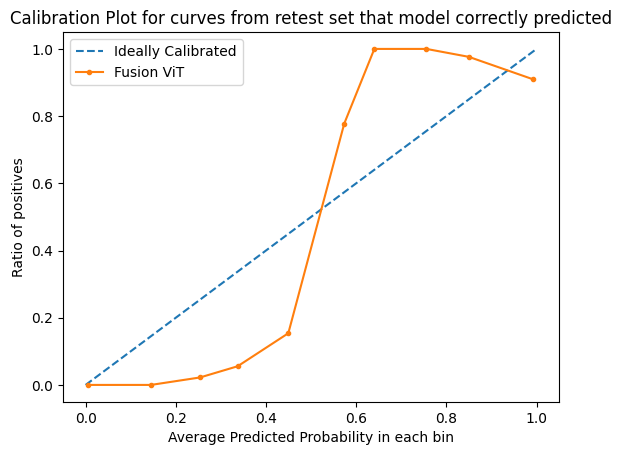

In [95]:
# best_acc_retest_df.head()
calibration_df = (best_acc_retest_df
                  .loc[(best_acc_retest_df.sample_pred_3 != 'ReSample') &
                       (best_acc_retest_df.final_patient_result == best_acc_retest_df.sample_pred_3)])

x,y = calibration_curve(calibration_df.groundtruth_label, calibration_df.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Calibration Plot for curves from retest set that model correctly predicted')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()

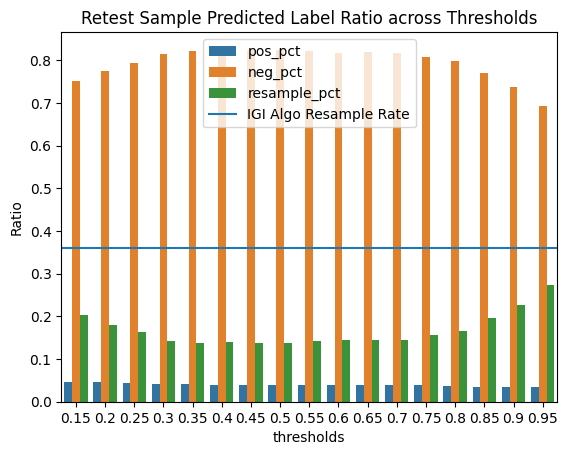

In [100]:
thresholds, pos_preds, neg_preds, resample_preds = [],[],[],[]

for i in range(15,100,5):
    retest_sample_df = retest_df.copy()
    retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= i/100)

    invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

    retest_sample_df = (retest_sample_df
                        .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
    .groupby(['sample_id','current_sample_result','final_patient_result'])
    .agg(sample_prob = ('pred', 'mean'))
    .reset_index())
    
    n_samples = retest_sample_df.shape[0]

    thresholds.append(i/100)
    pos_preds.append(retest_sample_df.loc[retest_sample_df.sample_prob > 0.5].shape[0]/n_samples)
    neg_preds.append(retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id))].shape[0]/n_samples)
    resample_preds.append((retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id))].shape[0] +
                            retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5)].shape[0])/n_samples)


threshold_retest_sample_df = pd.DataFrame({'thresholds': thresholds,
                                           'pos_pct': pos_preds,
                                           'neg_pct': neg_preds,
                                           'resample_pct': resample_preds})

hist_df = threshold_retest_sample_df.melt(id_vars=['thresholds'], var_name = 'Label', value_name = 'Ratio')

sns.barplot(data=hist_df, x='thresholds', y='Ratio', hue='Label', dodge=True)
plt.axhline(y=igi_algo_retest_sample_rate, label='IGI Algo Resample Rate')
plt.title('Retest Sample Predicted Label Ratio across Thresholds')
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


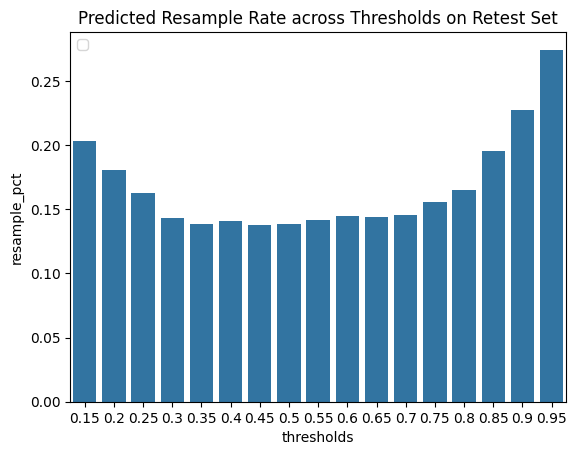

In [101]:
sns.barplot(data=threshold_retest_sample_df, x='thresholds', y='resample_pct')
plt.title('Predicted Resample Rate across Thresholds on Retest Set')
plt.legend()

### Methods to get thresholds
#### a) All sets
##### a.1) Same Threshold

Thresholds: {'RnaseP': 0.5441441441441441, 'MS2': 0.5441441441441441, 'S gene': 0.5441441441441441, 'E gene': 0.5441441441441441, 'ORF1ab': 0.5441441441441441, 'N gene': 0.5441441441441441}
-------------
Using the same thresholds from all set best accuracy, on all training curves
-------------
Model accuracy: 0.9881662261019242
Model precision: 0.9945951528504544
Model sensitivity: 0.9921700607850544
Model F1 score: 0.9933811267557205
Model TP = 28891; TN = 3258; FP = 157; FN = 228
Model FNR = 0.06540447504302926 and FPR = 0.00540484714954558
-------------
On retest curves
-------------
Model accuracy: 0.9333986287952988
Model precision: 0.8447782546494993
Model sensitivity: 0.9555016181229773
Model F1 score: 0.8967350037965072
Model TP = 1181; TN = 2631; FP = 217; FN = 55
Model FNR = 0.020476545048399106 and FPR = 0.1552217453505007
-------------
On Retest sample level
-------------
Model accuracy: 0.7766990291262136
Model FPR: 0.12765957446808507
Model FNR: 0.10334645669291342
Resamp

Text(0.5, 1.0, 'Same Threshold from All sets')

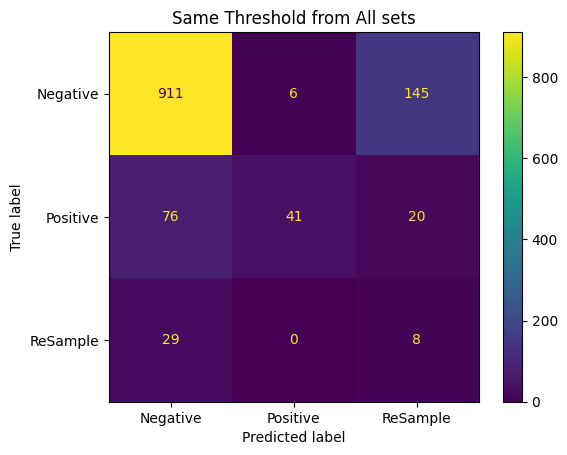

In [107]:
target_thresholds = {}
for target in fusion_train_pred.target.unique():

    thresholds = np.linspace(0.1, 1, 1000)
    accuracy_ls = []
    for thres in thresholds:
        df = fusion_train_pred
        pred = 1*(df.outputs >= thres)
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, pred).ravel()
        accuracy_ls.append((tp + tn)/(tp+tn+fp+fn))

    target_thresholds[target] = thresholds[np.array(accuracy_ls).argmax()]

print(f'Thresholds: {target_thresholds}')

best_threshold = target_thresholds['N gene']
fusion_train_pred['pred'] = 1
for target in fusion_train_pred.target.unique():
    fusion_train_pred.loc[fusion_train_pred.target == target, 'pred'] = 1*(fusion_train_pred.loc[fusion_train_pred.target == target, 'outputs'] >= target_thresholds[target])

train_tn, train_fp, train_fn, train_tp = confusion_matrix(fusion_train_pred.groundtruth_label, fusion_train_pred.pred).ravel()

train_precision = train_tp/(train_fp + train_tp)
train_sensitivity = train_tp/(train_tp + train_fn)
train_specificity = train_tn/(train_tn + train_fp)
train_f1 = 2*train_tp/(2*train_tp + train_fp + train_fn)
train_acc = (train_tp+train_tn)/(train_tp+train_tn+train_fp+train_fn)
train_fnr = train_fn/(train_fn + train_tn)
train_fpr = train_fp/(train_fp+train_tp)
train_tpr = (train_tp)/(train_tp + train_fp)

print('-------------')
print(f'Using the same thresholds from all set best accuracy, on all training curves')
print('-------------')
print(f'Model accuracy: {train_acc}')
print(f'Model precision: {train_precision}')
print(f'Model sensitivity: {train_sensitivity}')
print(f'Model F1 score: {train_f1}')
print(f'Model TP = {train_tp}; TN = {train_tn}; FP = {train_fp}; FN = {train_fn}')
print(f'Model FNR = {train_fnr} and FPR = {train_fpr}')


retest_df['pred'] = 1
for target in retest_df.target.unique():
    retest_df.loc[retest_df.target == target, 'pred'] = 1*(retest_df.loc[retest_df.target == target, 'outputs'] >= target_thresholds[target])

retest_tn, retest_fp, retest_fn, retest_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.pred).ravel()

retest_precision = retest_tp/(retest_fp + retest_tp)
retest_sensitivity = retest_tp/(retest_tp + retest_fn)
retest_specificity = retest_tn/(retest_tn + retest_fp)
retest_f1 = 2*retest_tp/(2*retest_tp + retest_fp + retest_fn)
retest_acc = (retest_tp+retest_tn)/(retest_tp+retest_tn+retest_fp+retest_fn)
retest_fnr = retest_fn/(retest_fn + retest_tn)
retest_fpr = retest_fp/(retest_fp+retest_tp)
retest_tpr = (retest_tp)/(retest_tp + retest_fp)

print('-------------')
print('On retest curves')
print('-------------')
print(f'Model accuracy: {retest_acc}')
print(f'Model precision: {retest_precision}')
print(f'Model sensitivity: {retest_sensitivity}')
print(f'Model F1 score: {retest_f1}')
print(f'Model TP = {retest_tp}; TN = {retest_tn}; FP = {retest_fp}; FN = {retest_fn}')
print(f'Model FNR = {retest_fnr} and FPR = {retest_fpr}')


retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1
for target in retest_sample_df.target.unique():
    retest_sample_df.loc[retest_sample_df.target == target, 'pred'] = 1*(retest_sample_df.loc[retest_sample_df.target == target, 'outputs'] >= target_thresholds[target])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])

print('-------------')
print('On Retest sample level')
print('-------------')
print(f'Model accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=1).sum())}')
print(f'Model FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'Model FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'Resample Rate: {cm.sum(axis=0)[2]/retest_sample_df.shape[0]}')

ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Same Threshold from All sets')


#### a.2) By target

Thresholds: {'RnaseP': 0.4864864864864865, 'MS2': 0.5513513513513514, 'S gene': 0.2792792792792793, 'E gene': 0.3441441441441442, 'ORF1ab': 0.536036036036036, 'N gene': 0.1945945945945946}
-------------
Using the same thresholds from all set best accuracy, on all training curves
-------------
Model accuracy: 0.9885658080777033
Model precision: 0.993680233556586
Model sensitivity: 0.9935437343315361
Model F1 score: 0.9936119792561047
Model TP = 28931; TN = 3231; FP = 184; FN = 188
Model FNR = 0.05498683825680024 and FPR = 0.006319766443414048
-------------
On retest curves
-------------
Model accuracy: 0.9133202742409402
Model precision: 0.7936085219707057
Model sensitivity: 0.9644012944983819
Model F1 score: 0.870708546384222
Model TP = 1192; TN = 2538; FP = 310; FN = 44
Model FNR = 0.017041053446940357 and FPR = 0.20639147802929428
-------------
On Retest sample level
-------------
Model accuracy: 0.7346278317152104
Model FPR: 0.2222222222222222
Model FNR: 0.09158679446219387
Resample

Text(0.5, 1.0, 'Thresholding by Target from All sets')

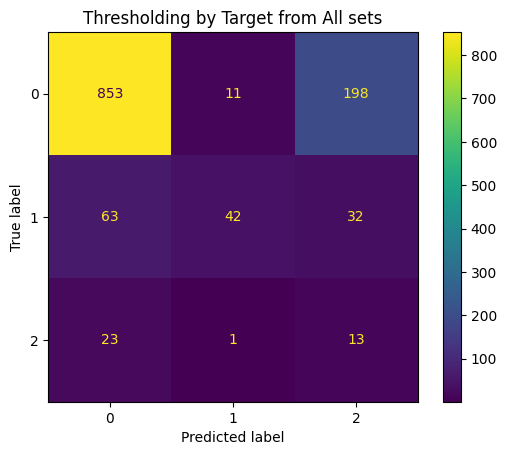

In [69]:
target_thresholds = {}
for target in fusion_train_pred.target.unique():

    thresholds = np.linspace(0.1, 1, 1000)
    accuracy_ls = []
    for thres in thresholds:
        df = fusion_train_pred[fusion_train_pred.target == target]
        pred = 1*(df.outputs >= thres)
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, pred).ravel()
        accuracy_ls.append((tp + tn)/(tp+tn+fp+fn))

    target_thresholds[target] = thresholds[np.array(accuracy_ls).argmax()]

print(f'Thresholds: {target_thresholds}')

fusion_train_pred['pred'] = 1
for target in fusion_train_pred.target.unique():
    fusion_train_pred.loc[fusion_train_pred.target == target, 'pred'] = 1*(fusion_train_pred.loc[fusion_train_pred.target == target, 'outputs'] >= target_thresholds[target])

train_tn, train_fp, train_fn, train_tp = confusion_matrix(fusion_train_pred.groundtruth_label, fusion_train_pred.pred).ravel()

train_precision = train_tp/(train_fp + train_tp)
train_sensitivity = train_tp/(train_tp + train_fn)
train_specificity = train_tn/(train_tn + train_fp)
train_f1 = 2*train_tp/(2*train_tp + train_fp + train_fn)
train_acc = (train_tp+train_tn)/(train_tp+train_tn+train_fp+train_fn)
train_fnr = train_fn/(train_fn + train_tn)
train_fpr = train_fp/(train_fp+train_tp)
train_tpr = (train_tp)/(train_tp + train_fp)

print('-------------')
print(f'Using the same thresholds from all set best accuracy, on all training curves')
print('-------------')
print(f'Model accuracy: {train_acc}')
print(f'Model precision: {train_precision}')
print(f'Model sensitivity: {train_sensitivity}')
print(f'Model F1 score: {train_f1}')
print(f'Model TP = {train_tp}; TN = {train_tn}; FP = {train_fp}; FN = {train_fn}')
print(f'Model FNR = {train_fnr} and FPR = {train_fpr}')


retest_df['pred'] = 1
for target in retest_df.target.unique():
    retest_df.loc[retest_df.target == target, 'pred'] = 1*(retest_df.loc[retest_df.target == target, 'outputs'] >= target_thresholds[target])

retest_tn, retest_fp, retest_fn, retest_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.pred).ravel()

retest_precision = retest_tp/(retest_fp + retest_tp)
retest_sensitivity = retest_tp/(retest_tp + retest_fn)
retest_specificity = retest_tn/(retest_tn + retest_fp)
retest_f1 = 2*retest_tp/(2*retest_tp + retest_fp + retest_fn)
retest_acc = (retest_tp+retest_tn)/(retest_tp+retest_tn+retest_fp+retest_fn)
retest_fnr = retest_fn/(retest_fn + retest_tn)
retest_fpr = retest_fp/(retest_fp+retest_tp)
retest_tpr = (retest_tp)/(retest_tp + retest_fp)

print('-------------')
print('On retest curves')
print('-------------')
print(f'Model accuracy: {retest_acc}')
print(f'Model precision: {retest_precision}')
print(f'Model sensitivity: {retest_sensitivity}')
print(f'Model F1 score: {retest_f1}')
print(f'Model TP = {retest_tp}; TN = {retest_tn}; FP = {retest_fp}; FN = {retest_fn}')
print(f'Model FNR = {retest_fnr} and FPR = {retest_fpr}')


retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1
for target in retest_sample_df.target.unique():
    retest_sample_df.loc[retest_sample_df.target == target, 'pred'] = 1*(retest_sample_df.loc[retest_sample_df.target == target, 'outputs'] >= target_thresholds[target])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])

print('-------------')
print('On Retest sample level')
print('-------------')
print(f'Model accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=1).sum())}')
print(f'Model FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'Model FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'Resample Rate: {cm.sum(axis=0)[2]/retest_sample_df.shape[0]}')

ConfusionMatrixDisplay(cm).plot()
plt.title('Thresholding by Target from All sets')

#### b) Test Set
##### b.1) Same Threshold

Thresholds: {'RnaseP': 0.5657657657657658, 'MS2': 0.5657657657657658, 'E gene': 0.5657657657657658, 'N gene': 0.5657657657657658, 'ORF1ab': 0.5657657657657658, 'S gene': 0.5657657657657658}
-------------
Using the same thresholds from all set best accuracy, on all training curves
-------------
Model accuracy: 0.9872064777327936
Model precision: 0.9938639234795164
Model sensitivity: 0.9918948126801153
Model F1 score: 0.9928783917785992
Model TP = 5507; TN = 589; FP = 34; FN = 45
Model FNR = 0.07097791798107256 and FPR = 0.006136076520483667
-------------
On retest curves
-------------
Model accuracy: 0.9324191968658179
Model precision: 0.8448275862068966
Model sensitivity: 0.9514563106796117
Model F1 score: 0.8949771689497716
Model TP = 1176; TN = 2632; FP = 216; FN = 60
Model FNR = 0.022288261515601784 and FPR = 0.15517241379310345
-------------
On Retest sample level
-------------
Model accuracy: 0.7750809061488673
Model FPR: 0.12765957446808507
Model FNR: 0.1027667984189723
Resample 

Text(0.5, 1.0, 'Same Threshold from Test set')

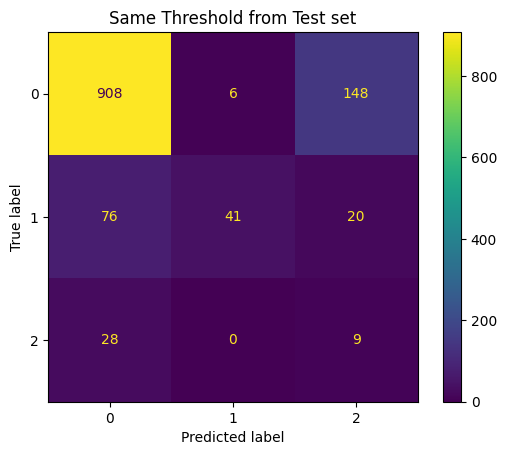

In [70]:
target_thresholds = {}
for target in fusion_vit_test_pred.target.unique():

    thresholds = np.linspace(0.1, 1, 1000)
    accuracy_ls = []
    for thres in thresholds:
        df = fusion_vit_test_pred
        pred = 1*(df.outputs >= thres)
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, pred).ravel()
        accuracy_ls.append((tp + tn)/(tp+tn+fp+fn))

    target_thresholds[target] = thresholds[np.array(accuracy_ls).argmax()]

print(f'Thresholds: {target_thresholds}')

fusion_vit_test_pred['pred'] = 1
for target in fusion_vit_test_pred.target.unique():
    fusion_vit_test_pred.loc[fusion_vit_test_pred.target == target, 'pred'] = 1*(fusion_vit_test_pred.loc[fusion_vit_test_pred.target == target, 'outputs'] >= target_thresholds[target])

train_tn, train_fp, train_fn, train_tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.pred).ravel()

train_precision = train_tp/(train_fp + train_tp)
train_sensitivity = train_tp/(train_tp + train_fn)
train_specificity = train_tn/(train_tn + train_fp)
train_f1 = 2*train_tp/(2*train_tp + train_fp + train_fn)
train_acc = (train_tp+train_tn)/(train_tp+train_tn+train_fp+train_fn)
train_fnr = train_fn/(train_fn + train_tn)
train_fpr = train_fp/(train_fp+train_tp)
train_tpr = (train_tp)/(train_tp + train_fp)

print('-------------')
print(f'Using the same thresholds from all set best accuracy, on all training curves')
print('-------------')
print(f'Model accuracy: {train_acc}')
print(f'Model precision: {train_precision}')
print(f'Model sensitivity: {train_sensitivity}')
print(f'Model F1 score: {train_f1}')
print(f'Model TP = {train_tp}; TN = {train_tn}; FP = {train_fp}; FN = {train_fn}')
print(f'Model FNR = {train_fnr} and FPR = {train_fpr}')


retest_df['pred'] = 1
for target in retest_df.target.unique():
    retest_df.loc[retest_df.target == target, 'pred'] = 1*(retest_df.loc[retest_df.target == target, 'outputs'] >= target_thresholds[target])

retest_tn, retest_fp, retest_fn, retest_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.pred).ravel()

retest_precision = retest_tp/(retest_fp + retest_tp)
retest_sensitivity = retest_tp/(retest_tp + retest_fn)
retest_specificity = retest_tn/(retest_tn + retest_fp)
retest_f1 = 2*retest_tp/(2*retest_tp + retest_fp + retest_fn)
retest_acc = (retest_tp+retest_tn)/(retest_tp+retest_tn+retest_fp+retest_fn)
retest_fnr = retest_fn/(retest_fn + retest_tn)
retest_fpr = retest_fp/(retest_fp+retest_tp)
retest_tpr = (retest_tp)/(retest_tp + retest_fp)

print('-------------')
print('On retest curves')
print('-------------')
print(f'Model accuracy: {retest_acc}')
print(f'Model precision: {retest_precision}')
print(f'Model sensitivity: {retest_sensitivity}')
print(f'Model F1 score: {retest_f1}')
print(f'Model TP = {retest_tp}; TN = {retest_tn}; FP = {retest_fp}; FN = {retest_fn}')
print(f'Model FNR = {retest_fnr} and FPR = {retest_fpr}')


retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1
for target in retest_sample_df.target.unique():
    retest_sample_df.loc[retest_sample_df.target == target, 'pred'] = 1*(retest_sample_df.loc[retest_sample_df.target == target, 'outputs'] >= target_thresholds[target])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])

print('-------------')
print('On Retest sample level')
print('-------------')
print(f'Model accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=1).sum())}')
print(f'Model FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'Model FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'Resample Rate: {cm.sum(axis=0)[2]/retest_sample_df.shape[0]}')

ConfusionMatrixDisplay(cm).plot()
plt.title('Same Threshold from Test set')


#### b.2) By target

Thresholds: {'RnaseP': 0.5648648648648649, 'MS2': 0.6, 'E gene': 0.2756756756756757, 'N gene': 0.21171171171171171, 'ORF1ab': 0.1, 'S gene': 0.8018018018018018}
-------------
Using the same thresholds from all set best accuracy, on all training curves
-------------
Model accuracy: 0.9880161943319838
Model precision: 0.9944043321299639
Model sensitivity: 0.9922550432276657
Model F1 score: 0.9933285250631085
Model TP = 5509; TN = 592; FP = 31; FN = 43
Model FNR = 0.06771653543307087 and FPR = 0.005595667870036101
-------------
On retest curves
-------------
Model accuracy: 0.9125857002938296
Model precision: 0.7991831177671885
Model sensitivity: 0.9498381877022654
Model F1 score: 0.8680221811460259
Model TP = 1174; TN = 2553; FP = 295; FN = 62
Model FNR = 0.023709369024856597 and FPR = 0.20081688223281144
-------------
On Retest sample level
-------------
Model accuracy: 0.7338187702265372
Model FPR: 0.2264150943396226
Model FNR: 0.09265175718849838
Resample Rate: 0.19741100323624594


Text(0.5, 1.0, 'Thresholding by Target from Test set')

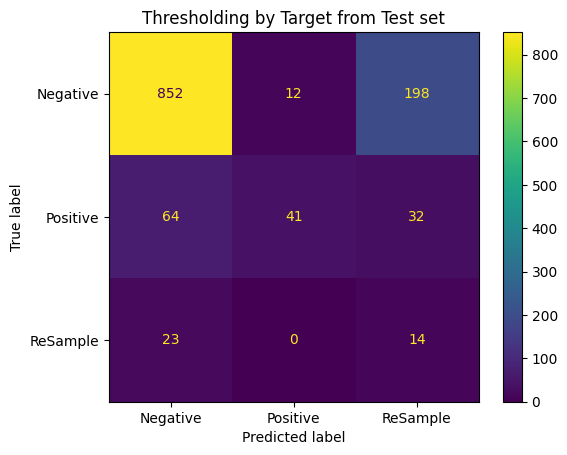

In [72]:
target_thresholds = {}
for target in fusion_vit_test_pred.target.unique():

    thresholds = np.linspace(0.1, 1, 1000)
    accuracy_ls = []
    for thres in thresholds:
        df = fusion_vit_test_pred[fusion_vit_test_pred.target == target]
        pred = 1*(df.outputs >= thres)
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, pred).ravel()
        accuracy_ls.append((tp + tn)/(tp+tn+fp+fn))

    target_thresholds[target] = thresholds[np.array(accuracy_ls).argmax()]

print(f'Thresholds: {target_thresholds}')

fusion_vit_test_pred['pred'] = 1
for target in fusion_vit_test_pred.target.unique():
    fusion_vit_test_pred.loc[fusion_vit_test_pred.target == target, 'pred'] = 1*(fusion_vit_test_pred.loc[fusion_vit_test_pred.target == target, 'outputs'] >= target_thresholds[target])

train_tn, train_fp, train_fn, train_tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.pred).ravel()

train_precision = train_tp/(train_fp + train_tp)
train_sensitivity = train_tp/(train_tp + train_fn)
train_specificity = train_tn/(train_tn + train_fp)
train_f1 = 2*train_tp/(2*train_tp + train_fp + train_fn)
train_acc = (train_tp+train_tn)/(train_tp+train_tn+train_fp+train_fn)
train_fnr = train_fn/(train_fn + train_tn)
train_fpr = train_fp/(train_fp+train_tp)
train_tpr = (train_tp)/(train_tp + train_fp)

print('-------------')
print(f'Using the same thresholds from all set best accuracy, on all training curves')
print('-------------')
print(f'Model accuracy: {train_acc}')
print(f'Model precision: {train_precision}')
print(f'Model sensitivity: {train_sensitivity}')
print(f'Model F1 score: {train_f1}')
print(f'Model TP = {train_tp}; TN = {train_tn}; FP = {train_fp}; FN = {train_fn}')
print(f'Model FNR = {train_fnr} and FPR = {train_fpr}')


retest_df['pred'] = 1
for target in retest_df.target.unique():
    retest_df.loc[retest_df.target == target, 'pred'] = 1*(retest_df.loc[retest_df.target == target, 'outputs'] >= target_thresholds[target])

retest_tn, retest_fp, retest_fn, retest_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.pred).ravel()

retest_precision = retest_tp/(retest_fp + retest_tp)
retest_sensitivity = retest_tp/(retest_tp + retest_fn)
retest_specificity = retest_tn/(retest_tn + retest_fp)
retest_f1 = 2*retest_tp/(2*retest_tp + retest_fp + retest_fn)
retest_acc = (retest_tp+retest_tn)/(retest_tp+retest_tn+retest_fp+retest_fn)
retest_fnr = retest_fn/(retest_fn + retest_tn)
retest_fpr = retest_fp/(retest_fp+retest_tp)
retest_tpr = (retest_tp)/(retest_tp + retest_fp)

print('-------------')
print('On retest curves')
print('-------------')
print(f'Model accuracy: {retest_acc}')
print(f'Model precision: {retest_precision}')
print(f'Model sensitivity: {retest_sensitivity}')
print(f'Model F1 score: {retest_f1}')
print(f'Model TP = {retest_tp}; TN = {retest_tn}; FP = {retest_fp}; FN = {retest_fn}')
print(f'Model FNR = {retest_fnr} and FPR = {retest_fpr}')


retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1
for target in retest_sample_df.target.unique():
    retest_sample_df.loc[retest_sample_df.target == target, 'pred'] = 1*(retest_sample_df.loc[retest_sample_df.target == target, 'outputs'] >= target_thresholds[target])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])

print('-------------')
print('On Retest sample level')
print('-------------')
print(f'Model accuracy: {(cm[0,0] + cm[1,1] + cm[2,2])/(cm.sum(axis=1).sum())}')
print(f'Model FPR: {1 - cm[1,1]/cm.sum(axis=0)[1]}')
print(f'Model FNR: {1 - cm[0,0]/(cm.sum(axis=0)[0])}')
print(f'Resample Rate: {cm.sum(axis=0)[2]/retest_sample_df.shape[0]}')

ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Thresholding by Target from Test set')


### Clinical Sample

In [112]:
clinical_sample_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_clinical_pred_df.csv')
clinical_sample_pred = (clinical_sample_pred
                        .merge(join_df, on = ['curve_idx']))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


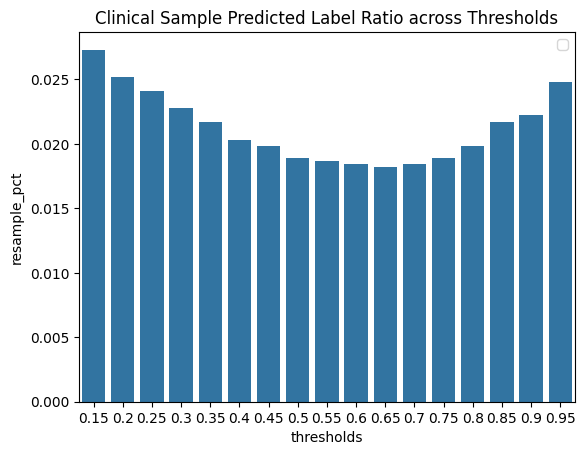

In [ ]:
thresholds, pos_preds, neg_preds, resample_preds = [],[],[],[]

for i in range(15,100,5):
    clinical_sample_df = clinical_sample_pred.copy()
    clinical_sample_df['pred'] = 1*(clinical_sample_df.outputs >= i/100)

    invalid_sample_id = clinical_sample_df[(clinical_sample_df.target.isin(['MS2','RnaseP'])) & (clinical_sample_df.pred == 0)].sample_id

    clinical_sample_df = (clinical_sample_df
                        .loc[~clinical_sample_df.target.isin(['MS2','RnaseP'])]
    .groupby(['sample_id','current_sample_result','final_patient_result'])
    .agg(sample_prob = ('pred', 'mean'))
    .reset_index())
    
    n_samples = clinical_sample_df.shape[0]

    thresholds.append(i/100)
    pos_preds.append(clinical_sample_df.loc[clinical_sample_df.sample_prob > 0.5].shape[0]/n_samples)
    neg_preds.append(clinical_sample_df.loc[(clinical_sample_df.sample_prob == 0) & (~clinical_sample_df.sample_id.isin(invalid_sample_id))].shape[0]/n_samples)
    resample_preds.append((clinical_sample_df.loc[(clinical_sample_df.sample_prob == 0) & (clinical_sample_df.sample_id.isin(invalid_sample_id))].shape[0] +
                            clinical_sample_df.loc[(clinical_sample_df.sample_prob > 0) & (clinical_sample_df.sample_prob <= 0.5)].shape[0])/n_samples)


threshold_clinical_sample_df = pd.DataFrame({'thresholds': thresholds,
                                           'pos_pct': pos_preds,
                                           'neg_pct': neg_preds,
                                           'resample_pct': resample_preds})
sns.barplot(data=threshold_clinical_sample_df, x='thresholds', y='resample_pct')
# plt.axhline(y=igi_algo_retest_sample_rate, label='IGI Algo')
plt.title('Clinical Sample Predicted Label Ratio across Thresholds')
plt.legend()


Apply the same threshold from all sets on clinical samples

In [113]:
clinical_sample_pred['pred'] = 1*(clinical_sample_pred.outputs >= best_threshold)

invalid_sample_id = clinical_sample_pred[(clinical_sample_pred.target.isin(['MS2','RnaseP'])) & (clinical_sample_pred.pred == 0)].sample_id

clinical_sample_df = (clinical_sample_pred
                    .loc[~clinical_sample_pred.target.isin(['MS2','RnaseP'])]
.groupby(['sample_id','current_sample_result','final_patient_result'])
.agg(sample_prob = ('pred', 'mean'))
.reset_index())

n_samples = clinical_sample_df.shape[0]

clinical_sample_df['sample_pred'] = None
clinical_sample_df.loc[clinical_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
clinical_sample_df.loc[(clinical_sample_df.sample_prob == 0) & (~clinical_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
clinical_sample_df.loc[(clinical_sample_df.sample_prob == 0) & (clinical_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
clinical_sample_df.loc[(clinical_sample_df.sample_prob > 0) & (clinical_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
clinical_sample_df['sample_pred_3'] = clinical_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
clinical_sample_df['current_sample_result_3'] = clinical_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

print(clinical_sample_df.groupby('sample_pred_3').sample_id.count())
print(clinical_sample_df.groupby('current_sample_result_3').sample_id.count())

sample_pred_3
Negative    17523
Positive     1452
ReSample      363
Name: sample_id, dtype: int64
current_sample_result_3
Negative    16472
Positive     1628
ReSample     1238
Name: sample_id, dtype: int64
